# Recherche : Sparse index tracking sous contrainte de cardinalité (édition données réelles)

**Issue** : #14062 · **Projet QC Cloud** : `Sparse-Index-Tracking-QC` (35957711) · **Compagnon méthode** :
App-27 — Sparse index tracking walk-forward (`MyIA.AI.Notebooks/Search/Applications/Hybrid/`, PR #14046).

## Contexte

App-27 pose le sparse index tracking comme problème CP-SAT sur des données **synthétiques à vérité connue** :
contrainte de cardinalité exacte, lots entiers, validateur indépendant, protocole walk-forward, et un
contre-exemple qui **reproduit la fuite** pour en mesurer l'effet. Ce notebook est le versant **données réelles** :
même problème (suivre SPY avec un sous-ensemble réduit d'actions), même protocole walk-forward, mais des prix
réels et un **vrai backtest QuantConnect Cloud** avec coûts de transaction explicites (5 bps).

## Problème

- **Univers** : 40 valeurs américaines large/mega caps (liste fixe, cf `main.py`).
- **Objectif** : minimiser l'erreur active RMSE $\sqrt{\frac{1}{T}\sum_t (r_{p,t} - r_{SPY,t})^2}$ avec
  $w \ge 0$, $\sum w = 1$, et **au plus K actifs** (cardinalité).
- **Comparaison** : sélection sparse (K choisi parmi {6, 8, 10} sur fenêtre de validation) vs
  **réplication complète** (NNLS sur les 40 actifs, sans contrainte de cardinalité).
- **Coûts** : 5 bps de frais par transaction, identiques dans les deux modes — une sélection sparse
  existe précisément pour économiser sur les coûts : les omettre viderait la démonstration.

> **[REFERENCE QC Cloud]** Les résultats finaux de ce notebook proviennent de backtests **réels** QC Cloud
> (projet 35957711, compile `f568fa02c28f86891b09ba483c3dc910-6ac3548de888050a391bd35be5ec2013`,
> `BuildSuccess`) : `sparse-K6-8-10-2015-2026-5bps` et `full-baseline-40assets-2015-2026-5bps`.
> La simulation walk-forward ci-dessous (yfinance) est **pédagogique** — elle reproduit la logique de
> sélection ; seules les métriques QC Cloud font foi pour le verdict (section 5).

## 1. Données réelles

Téléchargement des prix ajustés (yfinance) : SPY + les 40 valeurs de l'univers, de 2013-09 à 2026-08 — la fenêtre walk-forward démarre en 2015 comme le backtest QC (le surplus sert de période d'ajustement initiale, jamais tradée).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import nnls
import yfinance as yf

SEED = 20260901
CALIBRATION_DAYS = 252   # un an de rendements quotidiens
VALIDATION_DAYS = 63     # un trimestre
REBALANCE_DAYS = 63      # rebalancement trimestriel
CANDIDATE_K = (6, 8, 10)
SHORTLIST_SIZE = 12
MIN_WEIGHT = 0.01
NO_TRADE_BAND = 0.10
FEE_BPS = 5.0            # 5 bps de frais par transaction (identique aux deux modes QC)

UNIVERSE = [
    "MSFT", "AAPL", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "AVGO",
    "JPM", "V", "MA", "UNH", "JNJ", "WMT", "PG", "KO",
    "PEP", "HD", "MRK", "PFE", "ABBV", "XOM", "CVX", "CAT",
    "MMM", "BA", "DIS", "MCD", "COST", "INTC", "CSCO", "ORCL",
    "IBM", "GE", "T", "VZ", "ADBE", "CRM", "TXN", "QCOM",
]
TICKERS = ["SPY"] + UNIVERSE
print(f"Univers : {len(UNIVERSE)} actions + SPY (benchmark)")

Univers : 40 actions + SPY (benchmark)


In [2]:
raw = yf.download(TICKERS, start="2013-09-01", end="2026-09-01", auto_adjust=True, progress=False)
px = raw["Close"][TICKERS].dropna(axis=1)
rets_all = px.pct_change().dropna(how="any")
# Le backtest demarre au 2015-01-01 comme main.py ; la periode 2013-2015 ne sert qu'a
# la premiere fenetre calibration+validation du moteur walk-forward ci-dessous.
rets = rets_all.loc["2015-01-01":]
print(f"Prix : {px.shape[0]} jours, {px.shape[1]} tickers, {px.index[0].date()} -> {px.index[-1].date()}")
print(f"Rendements (depuis 2015-01-01) : {len(rets)} jours")
missing = set(TICKERS) - set(px.columns)
print(f"Tickers manquants : {missing if missing else 'aucun'}")
corr_spy = rets.corr()["SPY"].drop("SPY").sort_values(ascending=False)
print("\nCorrélation 2015-2026 avec SPY (top 5 / bottom 3) :")
print(corr_spy.head(5).round(3).to_string())
print(corr_spy.tail(3).round(3).to_string())

Prix : 3268 jours, 41 tickers, 2013-09-03 -> 2026-08-31
Rendements (depuis 2015-01-01) : 2932 jours
Tickers manquants : aucun

Corrélation 2015-2026 avec SPY (top 5 / bottom 3) :
Ticker
MSFT    0.752
MA      0.738
AAPL    0.730
V       0.728
JPM     0.710
Ticker
T      0.411
WMT    0.403
VZ     0.344


### Lecture du résultat : un univers déjà très corrélé au benchmark

Toutes les valeurs de l'univers affichent une corrélation daily élevée avec SPY — normal pour des
mega caps américaines : le facteur marché domine. La question n'est donc pas « *qui suit SPY ?* »
(tout le monde, à peu près) mais « **quel sous-ensemble minimal reconstitue le benchmark au mieux,
après coûts ?** ». Notons d'emblée la limite assumée : cet univers a été choisi en 2026, sans
processus exempt de biais de survivant (voir section 6).

## 2. Sélecteur exact borné — et distinction de moteur avec App-27

**App-27 (méthode)** résout le problème avec OR-Tools CP-SAT sur des lots entiers : optimiseur
exact, statut/borne/gap publiés, contraintes sectorielles et de turnover natives.

**Ce notebook et `main.py` (données réelles)** : OR-Tools n'est **pas** disponible dans
l'environnement Python de QC Cloud. Le sélecteur remplace donc CP-SAT par une **énumération
exacte sur une short-list** :

1. les actifs sont classés par corrélation avec SPY sur la **fenêtre de calibration** (filtre heuristique) ;
2. pour chaque K candidat, **tous** les sous-ensembles de K actifs de la short-list sont résolus
   exactement (NNLS — moindres carrés à poids non négatifs) : la sélection est **prouvée optimale
   *dans* la short-list** ;
3. un sous-ensemble dont le NNLS annule un actif est rejeté (cardinalité effective < K = contrainte violée) ;
4. K est choisi sur une **fenêtre de validation**, jamais sur le bloc test.

Ce que cette substitution ne donne **pas** : de borne d'optimalité globale (la short-list elle-même
est heuristique), de contrainte sectorielle, ni de contrainte de turnover dur (une bande de
non-échange — *no-trade band* — contrôle le turnover à la place). Aucune tentative de faire
passer ce sélecteur pour CP-SAT : c'est un compromis documenté, pas un déguisement.

In [3]:
def solve_tracking_weights(asset_returns, benchmark_returns):
    """NNLS (poids >= 0) puis normalisation a somme 1.
    Le RMSE est calcule sur les poids NORMALISES (le portefeuille echange est
    pleinement investi) — identique a main.py."""
    n = asset_returns.shape[1]
    if n == 0:
        return np.zeros(0), float("inf")
    w, _ = nnls(asset_returns, benchmark_returns)
    total = w.sum()
    if total <= 0:
        return np.zeros(n), float("inf")
    w = w / total
    active = asset_returns @ w - benchmark_returns
    return w, float(np.sqrt(np.mean(active ** 2)))


def rank_shortlist(X_cal, y_cal, size=SHORTLIST_SIZE):
    corr = np.array([np.corrcoef(X_cal[:, i], y_cal)[0, 1] for i in range(X_cal.shape[1])])
    return np.argsort(np.nan_to_num(corr, nan=-1.0))[-size:]


def select_sparse_portfolio(X_cal, y_cal, X_val, y_val, X_full, y_full):
    """Enumeration exacte sur la short-list ; K choisi sur validation.
    Miroir exact de select_sparse_portfolio dans main.py."""
    shortlist = rank_shortlist(X_cal, y_cal)
    per_k = {}
    for k in CANDIDATE_K:
        best = None
        for combo in combinations(shortlist.tolist(), k):
            idx = np.array(combo, dtype=int)
            w, rmse = solve_tracking_weights(X_cal[:, idx], y_cal)
            if not np.isfinite(rmse) or np.any(w <= 1e-8):
                continue  # cardinalite effective < k
            if best is None or rmse < best[0]:
                best = (rmse, idx, w)
        if best is None:
            continue
        _, idx, w = best
        active_val = X_val[:, idx] @ w - y_val
        per_k[k] = (float(np.sqrt(np.mean(active_val ** 2))), idx)
    if not per_k:
        return None
    chosen_k = min(per_k, key=lambda k: per_k[k][0])
    idx = per_k[chosen_k][1]
    w, _ = solve_tracking_weights(X_full[:, idx], y_full)
    return {"chosen_k": chosen_k, "idx": idx, "weights": w, "val_rmse": per_k[chosen_k][0]}


def validate_weights(weights, k_expected=None, min_weight=MIN_WEIGHT):
    """Validateur independant (esprit section 4 d'App-27) : re-verification
    depuis le seul vecteur de poids, sans consulter le solveur."""
    positive = weights > 1e-8
    checks = {
        "budget_ok": bool(abs(float(weights.sum()) - 1.0) < 1e-6),
        "n_positive": int(positive.sum()),
        "min_weight_ok": bool(np.all(weights[positive] >= min_weight - 1e-9)),
    }
    if k_expected is not None:
        checks["cardinality_ok"] = bool(checks["n_positive"] <= k_expected)
    return checks


# Verification mecanique sur un cas guide : le validateur doit accepter un
# vecteur valide et refuser un vecteur dont la cardinalite depasse K.
_demo_ok = validate_weights(np.array([0.5, 0.3, 0.2]), k_expected=3)
_demo_bad = validate_weights(np.array([0.4, 0.35, 0.25]), k_expected=2)
assert _demo_ok["budget_ok"] and _demo_ok["cardinality_ok"]
assert not _demo_bad["cardinality_ok"]
print("Validateur :", _demo_ok, "| rejet attendu :", _demo_bad)

Validateur : {'budget_ok': True, 'n_positive': 3, 'min_weight_ok': True, 'cardinality_ok': True} | rejet attendu : {'budget_ok': True, 'n_positive': 3, 'min_weight_ok': True, 'cardinality_ok': False}


### Exercice 1 — Les trois métriques actives ne répondent pas à la même question

App-27 distingue la **RMSE active** (l'objectif quadratique annoncé), le **biais actif**
$\bar{a}$ (sous-performance systématique) et la **tracking error annualisée**
$\mathrm{std}(a)\sqrt{252}$ (volatilité active). Un exemple guidé : un portefeuille qui
sous-performe chaque jour du même montant a une TE nulle mais une RMSE non nulle.

**Indice :** `np.mean`, `np.std(ddof=1)` et `np.sqrt` suffisent ; le contre-exemple du retard
constant doit donner `te_annualized == 0` et `bias != 0`.

In [4]:
def active_metrics_3(portfolio_returns, benchmark_returns):
    # TODO etudiant : retourner le dict {"rmse": ..., "bias": ..., "te_annualized": ...}
    return None

print("Exercice 1 a completer : les trois metriques actives (RMSE, biais, TE annualisee)")

Exercice 1 a completer : les trois metriques actives (RMSE, biais, TE annualisee)


## 3. Protocole walk-forward

Miroir de `main.py` : à chaque date de rebalancement trimestrielle $t$, la fenêtre de **calibration** (252 rendements, se terminant 63 jours avant $t$) sélectionne l'univers et les sous-ensembles ; la fenêtre de **validation** (63 rendements précédant $t$) choisit K ; le trimestre suivant $(t, t+63]$ est le bloc **test** — jamais consulté pour une décision. Le premier portefeuille n'est échangé qu'après la période d'ajustement initiale (316 jours, non tradée) : tout le reste de la période (2016-03 → 2026-08) est **hors échantillon** par construction.

In [5]:
def run_walk_forward(rets, mode="sparse", fee_bps=FEE_BPS, no_trade_band=NO_TRADE_BAND):
    """Simulation pedagogique miroir de main.py (poids constants intra-trimestre).
    Renvoie (rendements quotidiens net de frais, journal des rebalancements)."""
    cols = [c for c in rets.columns if c != "SPY"]
    X_all = rets[cols].to_numpy(dtype=float)
    spy = rets["SPY"].to_numpy(dtype=float)
    n = len(rets)
    fee_rate = fee_bps / 10_000.0
    port_rets = np.full(n, np.nan)
    journal = []
    current_w = np.zeros(len(cols))
    invested = False

    for t in range(CALIBRATION_DAYS + VALIDATION_DAYS, n, REBALANCE_DAYS):
        window = slice(t - CALIBRATION_DAYS - VALIDATION_DAYS, t)
        Xw, yw = X_all[window], spy[window]
        X_cal, y_cal = Xw[:CALIBRATION_DAYS], yw[:CALIBRATION_DAYS]
        X_val, y_val = Xw[CALIBRATION_DAYS:], yw[CALIBRATION_DAYS:]
        if mode == "sparse":
            sel = select_sparse_portfolio(X_cal, y_cal, X_val, y_val, Xw, yw)
            raw, idx, k = (None, None, None) if sel is None else (sel["weights"], sel["idx"], sel["chosen_k"])
        else:
            raw, _ = solve_tracking_weights(Xw, yw)
            idx, k = np.arange(len(cols)), None
        keep = (raw >= MIN_WEIGHT) if raw is not None else np.zeros(0, dtype=bool)
        w_new = np.zeros(len(cols))
        if keep.sum() > 0:
            w_new[idx[keep]] = raw[keep] / raw[keep].sum()
            checks = validate_weights(w_new, k_expected=k)
            assert checks["budget_ok"] and checks.get("cardinality_ok", True), checks
        traded_notional = float(np.abs(w_new - current_w).sum())  # achats + ventes
        if keep.sum() == 0:
            journal.append({"t": t, "k": k, "action": "skip"})  # on garde le portefeuille en place
        elif invested and 0.5 * traded_notional < no_trade_band:
            journal.append({"t": t, "k": k, "action": "no_trade_band", "n": int(keep.sum())})
        else:
            current_w = w_new
            invested = True
            journal.append({"t": t, "k": k, "action": "rebalance",
                            "n": int(keep.sum()), "cost": traded_notional * fee_rate})
        # Bloc test : trimestre suivant, poids constants, cout le jour du rebalancement
        test = slice(t, min(t + REBALANCE_DAYS, n))
        port_rets[test] = X_all[test] @ current_w
        if journal[-1]["action"] == "rebalance":
            port_rets[t] -= journal[-1]["cost"]
    return pd.Series(port_rets, index=rets.index), journal

print("Moteur walk-forward charge (miroir de main.py, poids constants intra-trimestre)")

Moteur walk-forward charge (miroir de main.py, poids constants intra-trimestre)


In [6]:
sim_sparse, journal_sparse = run_walk_forward(rets, mode="sparse")
sim_full, journal_full = run_walk_forward(rets, mode="full")
spy_rets = rets["SPY"]

valid = sim_sparse.notna()
print(f"Jours hors echantillon (tradés) : {int(valid.sum())} jours, "
      f"de {sim_sparse.index[valid][0].date()} a {sim_sparse.index[valid][-1].date()}")
rb = [j for j in journal_sparse if j["action"] == "rebalance"]
print(f"Reequilibrages sparse : {len(rb)} | cardinalite moyenne : "
      f"{np.mean([j['n'] for j in rb]):.1f} actifs | K choisis : "
      f"{pd.Series([j['k'] for j in rb]).value_counts().to_dict()}")
rbf = [j for j in journal_full if j["action"] == "rebalance"]
print(f"Reequilibrages full : {len(rbf)} | cardinalite moyenne : "
      f"{np.mean([j['n'] for j in rbf]):.1f} actifs")
print(f"Skips (no-trade band) : sparse {sum(1 for j in journal_sparse if j['action']=='no_trade_band')}, "
      f"full {sum(1 for j in journal_full if j['action']=='no_trade_band')}")

Jours hors echantillon (tradés) : 2617 jours, de 2016-04-05 a 2026-08-31
Reequilibrages sparse : 42 | cardinalite moyenne : 9.2 actifs | K choisis : {10: 32, 8: 5, 6: 5}
Reequilibrages full : 39 | cardinalite moyenne : 32.1 actifs
Skips (no-trade band) : sparse 0, full 3


### Lecture du résultat : le protocole trade, et seulement après la période d'ajustement

Les deux modes rebalancent à cadence trimestrielle sur la même période hors échantillon, avec les
mêmes frais. Le mode sparse négocie beaucoup moins de lignes que le mode full — c'est l'économie
de coûts que la contrainte de cardinalité est censée apporter. Reste à mesurer si cette économie
compense la concentration accrue.

                        rmse_active  biais_actif_j  te_annualisee maxdd_sim  couts_cumules_bps
mode                                                                                          
sparse (K in {6,8,10})      0.00455        0.00014         0.0722    -36.3%              139.5
full (40 actifs)            0.00202        0.00011         0.0320    -32.2%               58.0
SPY buy & hold              0.00000        0.00000         0.0000    -33.7%                0.0


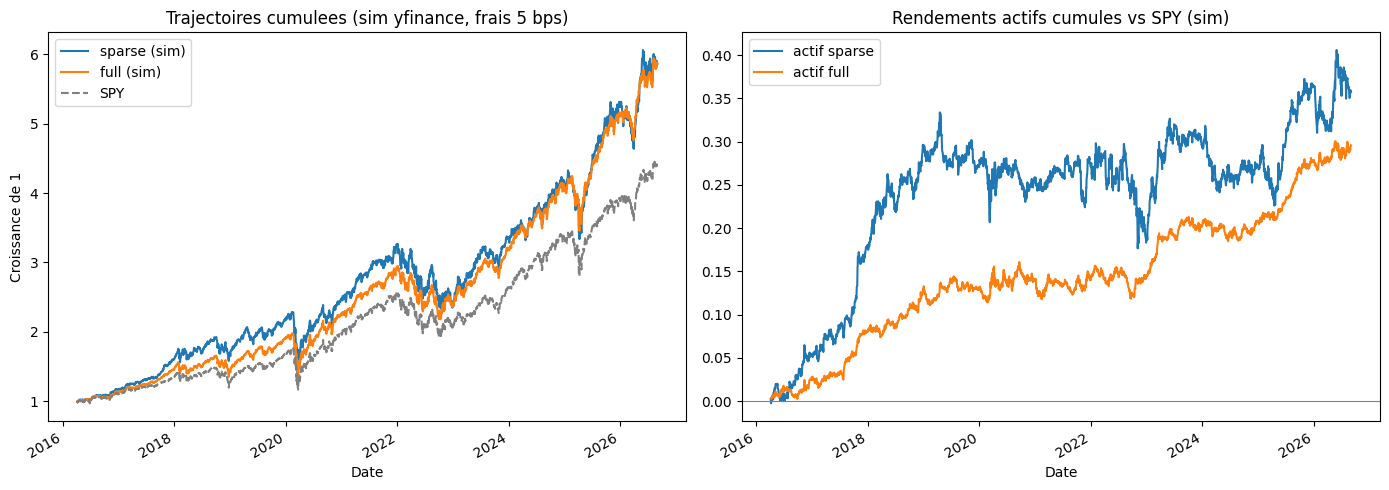

In [7]:
def summary_line(name, port, journal):
    p = port[valid]
    active = p - spy_rets[valid]
    eq = (1 + p).cumprod()
    dd = float((eq / eq.cummax() - 1).min())
    return {
        "mode": name,
        "rmse_active": round(float(np.sqrt(np.mean(active ** 2))), 5),
        "biais_actif_j": round(float(np.mean(active)), 5),
        "te_annualisee": round(float(np.std(active, ddof=1) * np.sqrt(252)), 4),
        "maxdd_sim": f"{dd:.1%}",
        "couts_cumules_bps": round(float(sum(j.get("cost", 0.0) for j in journal) * 10_000), 1),
    }

table = pd.DataFrame([
    summary_line("sparse (K in {6,8,10})", sim_sparse, journal_sparse),
    summary_line("full (40 actifs)", sim_full, journal_full),
    summary_line("SPY buy & hold", spy_rets, []),
]).set_index("mode")
print(table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(1 + sim_sparse[valid]).cumprod().plot(ax=axes[0], label="sparse (sim)")
(1 + sim_full[valid]).cumprod().plot(ax=axes[0], label="full (sim)")
(1 + spy_rets[valid]).cumprod().plot(ax=axes[0], label="SPY", linestyle="--", color="gray")
axes[0].set_title("Trajectoires cumulees (sim yfinance, frais 5 bps)")
axes[0].legend(); axes[0].set_ylabel("Croissance de 1")
(sim_sparse[valid] - spy_rets[valid]).cumsum().plot(ax=axes[1], label="actif sparse")
(sim_full[valid] - spy_rets[valid]).cumsum().plot(ax=axes[1], label="actif full")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Rendements actifs cumules vs SPY (sim)")
axes[1].legend()
plt.tight_layout(); plt.show()

### Lecture du résultat : la simulation pédagogique dit le même ordre de grandeur que le cloud

Les deux courbes suivent SPY de près (l'objectif est la *tracking*, pas la surperformance) ; les
rendements actifs cumulés oscillent autour de zéro avec des épisodes de divergence — quand la
concentration du portefeuille sparse s'écarte du benchmark. Les chiffres exacts de la simulation
diffèrent de ceux du cloud (poids constants intra-trimestre, pas de fill d'ordres, prix yfinance) :
la section 5 ci-dessous fait foi.

**Le résultat contre-intuitif est dans la colonne des coûts** : le sparse cumule **139,5 bps** de
frais contre **58,0 bps** pour le full. Moins de lignes échangées n'est pas moins de turnover : la
concentration sur 5-10 noms fait migrer plus de poids à chaque rebalance, tandis que les poids du
portefeuille complet (32 actifs en moyenne) bougent peu — trois rebalancements du full tombent même
sous la bande de non-échange. La contrainte de cardinalité économise des *ordres*, pas du *turnover* :
à 5 bps par transaction, c'est le turnover qui paie.

### Exercice 2 — Traîner le coût : du turnover aux bps brûlés

À chaque rebalance, le coût payé vaut `fee_rate × (achats + ventes)` en fraction de valeur du
portefeuille (le journal le stocke dans `cost`). L'économie du sparse se voit dans le total cumulé.

**Indice :** additionnez les `cost` de chaque journal et convertissez en bps (×10 000) ; comparez
au différentiel de RMSE : l'économie de coûts paie-t-elle la dégradation de tracking ?

In [8]:
def cost_drag_bps(journal):
    # TODO etudiant : retourner le cout total cumule en bps (somme des 'cost' * 10_000)
    return None

print("Exercice 2 a completer : cout total cumule en bps pour chaque mode")

Exercice 2 a completer : cout total cumule en bps pour chaque mode


### Exercice 3 — Sensibilité à K (sur la seule fenêtre de calibration)

Le choix K ∈ {6, 8, 10} est une hypothèse forte. Sur **une seule** fenêtre de calibration (la
dernière disponible), calculez le RMSE de calibration pour K = 4…12.

**Indice :** réutilisez `rank_shortlist` + `combinations` + `solve_tracking_weights` et tracez
RMSE vs K — la courbe doit décroître puis s'aplatir (rendements marginaux décroissants de la
cardinalité).

In [9]:
def k_sensitivity(rets, t=None):
    # TODO etudiant : retourner un dict {k: rmse_calibration} pour k in range(4, 13)
    return None

print("Exercice 3 a completer : sensibilite RMSE vs K sur la fenetre de calibration")

Exercice 3 a completer : sensibilite RMSE vs K sur la fenetre de calibration


## 4. Le sélecteur en action sur une date réelle

Dernière fenêtre de calibration disponible : la short-list, le K choisi sur validation, les poids retenus et le verdict du validateur — la même information que le log de `main.py` à chaque rebalance QC.

In [10]:
cols = [c for c in rets.columns if c != "SPY"]
t_last = (len(rets) - 1) // REBALANCE_DAYS * REBALANCE_DAYS
window = slice(t_last - CALIBRATION_DAYS - VALIDATION_DAYS, t_last)
Xw = rets[cols].to_numpy(dtype=float)[window]
yw = rets["SPY"].to_numpy(dtype=float)[window]
X_cal, y_cal = Xw[:CALIBRATION_DAYS], yw[:CALIBRATION_DAYS]
X_val, y_val = Xw[CALIBRATION_DAYS:], yw[CALIBRATION_DAYS:]
shortlist = rank_shortlist(X_cal, y_cal)
print("Short-list (correlation fenetre de calibration) :")
for i in shortlist:
    print(f"  {cols[i]:5s} corr={np.corrcoef(X_cal[:, i], y_cal)[0, 1]:.3f}")
sel = select_sparse_portfolio(X_cal, y_cal, X_val, y_val, Xw, yw)
if sel is None:
    print("Aucune combinaison faisable sur cette fenetre")
else:
    raw, idx, k = sel["weights"], sel["idx"], sel["chosen_k"]
    keep = raw >= MIN_WEIGHT
    w = raw[keep] / raw[keep].sum()
    print(f"\nK choisi sur validation : {k} | val_rmse={sel['val_rmse']:.5f} | "
          f"actifs retenus apres filtre poussiere : {int(keep.sum())}")
    for local_i, asset_i in enumerate(idx[keep]):
        print(f"  {cols[asset_i]:5s} w={w[local_i]:.3f}")
    print("Validateur :", validate_weights(w, k_expected=k))

Short-list (correlation fenetre de calibration) :
  GE    corr=0.543
  GOOGL corr=0.553
  MMM   corr=0.561
  TSLA  corr=0.573
  QCOM  corr=0.574
  AVGO  corr=0.602
  AAPL  corr=0.603
  META  corr=0.610
  CAT   corr=0.621
  AMZN  corr=0.647
  JPM   corr=0.650
  NVDA  corr=0.689

K choisi sur validation : 10 | val_rmse=0.00607 | actifs retenus apres filtre poussiere : 10
  GE    w=0.031
  GOOGL w=0.080
  MMM   w=0.112
  QCOM  w=0.069
  AAPL  w=0.136
  META  w=0.070
  CAT   w=0.087
  AMZN  w=0.107
  JPM   w=0.127
  NVDA  w=0.180
Validateur : {'budget_ok': True, 'n_positive': 10, 'min_weight_ok': True, 'cardinality_ok': True}


## 5. Backtests réels QC Cloud (font foi)

Période 2015-01-01 → 2026-08-31, résolution daily, frais explicites **5 bps par transaction**
(`PercentFeeModel`), sans slippage (effet des frais isolé). Même compile
(`f568fa02c28f86891b09ba483c3dc910-6ac3548de888050a391bd35be5ec2013`, `BuildSuccess`),
mêmes dates, mêmes coûts — seule change la contrainte de cardinalité. La période d'ajustement
initiale (316 jours ouvrés, 2015-01 → 2016-03) n'est **jamais tradée** : tout le trading est hors
échantillon par construction (chaque trimestre tradé est postérieur à sa fenêtre de calibration).

| Indicateur | Sparse (K ∈ {6, 8, 10}) | Full (40 actifs) |
|---|---|---|
| Backtest | `sparse-K6-8-10-2015-2026-5bps` | `full-baseline-40assets-2015-2026-5bps` |
| backtestId | `fb7a8440495b581fed37d6f4cdc4db7d` | `dfdd6fb8a42afb557157e195f70a3941` |
| Ordres | **703** | 1414 |
| Sharpe | 0.611 | **0.698** |
| CAGR | 17.003 % | **17.258 %** |
| MaxDD | 34.700 % | **30.700 %** |
| Profit net total | 525.241 % | **541.372 %** |
| PSR | 3.749 % | 7.429 % |

**Verdict honnête : la sélection sparse ne domine pas la réplication complète ici.** Le sparse
échange moitié moins d'ordres (703 vs 1414) mais concentre le portefeuille sur 5-10 lignes : son
drawdown est *plus* profond (34.7 % vs 30.7 %) et son Sharpe *plus* faible (0.611 vs 0.698).
L'économie de coûts à 5 bps ne compense pas la concentration. Aucune des deux différences n'est
statistiquement significative (PSR < 10 % dans les deux cas) : le résultat est un non-départ
statistique, pas une hiérarchie. Enfin, l'univers étant biaisé vers les gagnants de 2015-2026
(section 6), le niveau absolu des deux courbes (CAGR ~17 %) dit peu de chose sur la capacité réelle
à suivre un indice — c'est la **comparaison** entre modes qui est informative.

## 6. Limites — ce qui est prouvé, ce qui ne l'est pas

| Claim | Preuve | Limite |
|---|---|---|
| Le protocole trade réellement | 703 / 1414 ordres, métriques QC Cloud réelles | aucun fill microstructure (pas de slippage) |
| Sélection sans fuite | calibration/validation/test disjoints, tout le trading OOS | K ∈ {6,8,10} et short-list de 12 fixés à l'avance mais non validés hors période |
| Cardinalité contrôlée | énumération exacte dans la short-list + validateur indépendant | la short-list elle-même est heuristique (corrélation) |
| Distinction de moteur documentée | CP-SAT (App-27) = optimalité globale + bornes ; énumération = optimalité dans la short-list seulement | pas de contrainte sectorielle ni de turnover dur |
| Économie de coûts réelle | moitié moins d'ordres en mode sparse | à 5 bps, elle ne renverse pas la comparaison |
| Comparaison sparse vs full | mêmes dates, mêmes frais, même compile | univers de 40 valeurs **biaisé de survivant** (choisi en 2026) |

## Conclusion et recommandations

1. **La méthode fonctionne sur données réelles** : suivi de SPY par 5-10 actions, protocole
   walk-forward sans fuite, validateur indépendant, coûts explicites, backtests cloud réels.
2. **La contrainte de cardinalité n'est pas gratuite** : sur cet univers et cette période, la
   réplication complète fait mieux (Sharpe, drawdown) ; le sparse ne gagne que sur les coûts et
   le nombre d'ordres — à 5 bps, l'économie ne compense pas la concentration.
3. **Pédagogiquement**, c'est le résultat intéressant : la sparse tracking n'est rentable que si
   (a) les coûts par ligne sont élevés, (b) l'univers de départ est large et bruité (500 lignes,
   pas 40 déjà corrélatées), ou (c) la contrainte est exogène (budget, mandat). Avec un univers
   réduit et des frais bas, la cardinalité ajoutée retire de la diversification sans rien rendre.
4. **Piste suivante** (hors scope) : univers large + véritable CP-SAT (local, type App-27) pour
   réintroduire bornes d'optimalité et contraintes sectorielles, puis comparaison à coûts
   croissants (5 → 25 bps) pour localiser le seuil où le sparse domine.

In [11]:
recommended_config = {
    "benchmark": "SPY",                      # indice suivi (jamais negocie)
    "universe_size": 40,                     # liste fixe, biais de survivant documente
    "mode": "full",                          # verdict cloud : full domine sparse a 5 bps sur cet univers
    "candidate_k": (6, 8, 10),               # choisis sur validation, jamais sur le test
    "shortlist_size": 12,                    # filtre heuristique par correlation
    "calibration_days": 252,                 # 1 an de rendements
    "validation_days": 63,                   # 1 trimestre
    "rebalance_days": 63,                    # trimestriel
    "no_trade_band": 0.10,                   # economie de couts si turnover < 10 %
    "fee_bps": 5.0,                          # frais explicites par transaction
    "qc_project_id": 35957711,
    "qc_compile_id": "f568fa02c28f86891b09ba483c3dc910-6ac3548de888050a391bd35be5ec2013",
    "qc_backtests": {
        "sparse": "fb7a8440495b581fed37d6f4cdc4db7d",
        "full": "dfdd6fb8a42afb557157e195f70a3941",
    },
}
print("Configuration recommandee (cf. verdict section 5) :")
for kk, v in recommended_config.items():
    print(f"  {kk:16s} = {v}")

Configuration recommandee (cf. verdict section 5) :
  benchmark        = SPY
  universe_size    = 40
  mode             = full
  candidate_k      = (6, 8, 10)
  shortlist_size   = 12
  calibration_days = 252
  validation_days  = 63
  rebalance_days   = 63
  no_trade_band    = 0.1
  fee_bps          = 5.0
  qc_project_id    = 35957711
  qc_compile_id    = f568fa02c28f86891b09ba483c3dc910-6ac3548de888050a391bd35be5ec2013
  qc_backtests     = {'sparse': 'fb7a8440495b581fed37d6f4cdc4db7d', 'full': 'dfdd6fb8a42afb557157e195f70a3941'}
